In [ ]:
import huggingface_hub
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(hf_token)

In [ ]:
import torch
import torch.nn as nn
from typing import Optional, Tuple, Callable, Union

# 型ヒントと設定用
from transformers.models.llama.configuration_llama import LlamaConfig
from transformers.cache_utils import Cache
from transformers.utils import logging
from transformers.utils.deprecation import deprecate_kwarg

# Llama固有の計算ロジック（RoPEや標準Attention）
from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS
from transformers.models.llama.modeling_llama import (
    apply_rotary_pos_emb,
    repeat_kv,
    # eager_attention_forward, # 自分で定義
)

# 特殊な型定義（4.57.xで厳密に合わせる場合）
try:
    from typing import Unpack
except ImportError:
    from typing_extensions import Unpack
from transformers.utils import TransformersKwargs

logger = logging.get_logger(__name__)

def eager_attention_forward(
    module: nn.Module,
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    attention_mask: Optional[torch.Tensor],
    scaling: float,
    dropout: float = 0.0,
    **kwargs: Unpack[TransformersKwargs],
):
    key_states = repeat_kv(key, module.num_key_value_groups)
    value_states = repeat_kv(value, module.num_key_value_groups)

    attn_weights = torch.matmul(query, key_states.transpose(2, 3)) * scaling
    if attention_mask is not None:
        causal_mask = attention_mask[:, :, :, : key_states.shape[-2]]
        attn_weights = attn_weights + causal_mask

    attn_weights = nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query.dtype)
    attn_weights = nn.functional.dropout(attn_weights, p=dropout, training=module.training)
    attn_output = torch.matmul(attn_weights, value_states)
    attn_output = attn_output.transpose(1, 2).contiguous()

    return attn_output, attn_weights


class VicunaAttention(nn.Module):
    """Multi-headed attention from 'Attention Is All You Need' paper"""

    def __init__(self, config: LlamaConfig, layer_idx: int):
        super().__init__()
        self.config = config
        self.layer_idx = layer_idx
        self.head_dim = getattr(config, "head_dim", config.hidden_size // config.num_attention_heads)
        self.num_key_value_groups = config.num_attention_heads // config.num_key_value_heads
        self.scaling = self.head_dim**-0.5
        self.attention_dropout = config.attention_dropout
        self.is_causal = True

        self.q_proj = nn.Linear(
            config.hidden_size, config.num_attention_heads * self.head_dim, bias=config.attention_bias
        )
        self.k_proj = nn.Linear(
            config.hidden_size, config.num_key_value_heads * self.head_dim, bias=config.attention_bias
        )
        self.v_proj = nn.Linear(
            config.hidden_size, config.num_key_value_heads * self.head_dim, bias=config.attention_bias
        )
        self.o_proj = nn.Linear(
            config.num_attention_heads * self.head_dim, config.hidden_size, bias=config.attention_bias
        )

    @deprecate_kwarg("past_key_value", new_name="past_key_values", version="4.58")
    def forward(
        self,
        hidden_states: torch.Tensor,
        position_embeddings: tuple[torch.Tensor, torch.Tensor],
        attention_mask: Optional[torch.Tensor],
        past_key_values: Optional[Cache] = None,
        cache_position: Optional[torch.LongTensor] = None,
        **kwargs: Unpack[TransformersKwargs],
    ) -> tuple[torch.Tensor, torch.Tensor]:
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)

        query_states = self.q_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        key_states = self.k_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

        cos, sin = position_embeddings
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_values is not None:
            # sin and cos are specific to RoPE models; cache_position needed for the static cache
            cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
            key_states, value_states = past_key_values.update(key_states, value_states, self.layer_idx, cache_kwargs)

        attention_interface: Callable = eager_attention_forward
        if self.config._attn_implementation != "eager":
            attention_interface = ALL_ATTENTION_FUNCTIONS[self.config._attn_implementation]

        attn_output, attn_weights = attention_interface(
            self,
            query_states,
            key_states,
            value_states,
            attention_mask,
            dropout=0.0 if not self.training else self.attention_dropout,
            scaling=self.scaling,
            **kwargs,
        )

        attn_output = attn_output.reshape(*input_shape, -1).contiguous()
        attn_output = self.o_proj(attn_output)
        return attn_output, attn_weights


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# モデルIDの指定（Vicuna 7B v1.5 の場合）
model_id = "lmsys/vicuna-7b-v1.5"

# トークナイザーとモデルの読み込み
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16, # 半精度で読み込み
    device_map="auto",         # GPUに自動割り当て
    attn_implementation = "eager"
)

target_layers = list(range(14,20))

# 全レイヤー入れ替え
for i, layer in enumerate(model.model.layers):
    if i in target_layers:
        original_attn = layer.self_attn
        target_device = original_attn.q_proj.weight.device
        target_dtype = original_attn.q_proj.weight.dtype

        new_attn = VicunaAttention(config=model.config, layer_idx=i)

        # originalの情報をコピー
        new_attn.load_state_dict(original_attn.state_dict(), strict=False)
        new_attn.to(device=target_device, dtype=target_dtype)
        layer.self_attn = new_attn
    else: pass

# Vicuna専用のプロンプトテンプレート
def build_prompt(user_query):
    return (
        "A chat between a curious user and an artificial intelligence assistant. "
        "The assistant gives helpful, detailed, and polite answers to the user's questions. "
        f"USER: {user_query} "
        "ASSISTANT:"
    )

# 入力テキストの設定
user_input = "美味しいカレーの作り方を教えてください。"
prompt = build_prompt(user_input)

# 推論の実行
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=512,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

# 結果のデコード
response = tokenizer.decode(output_ids[0][input_ids.shape[-1]:], skip_special_tokens=True)
print(response)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

美味しいカレーの作り方をご紹介します。

【材料】
・合挽き肉 300


In [ ]:
import gc
gc.collect()

del output_ids
torch.cuda.empty_cache()


In [ ]:
from transformers import AutoConfig
import transformers

config = AutoConfig.from_pretrained("lmsys/vicuna-7b-v1.5")
print(config.architectures)
# 出力: ['LlamaForCausalLM']

print(transformers.__version__)

['LlamaForCausalLM']
4.57.6


Max count in 6 trials: 2
Number of overlapping cells (count > 1) in 6 trials: 14
Max count in 12 trials: 4
Number of overlapping cells (count > 1) in 12 trials: 50


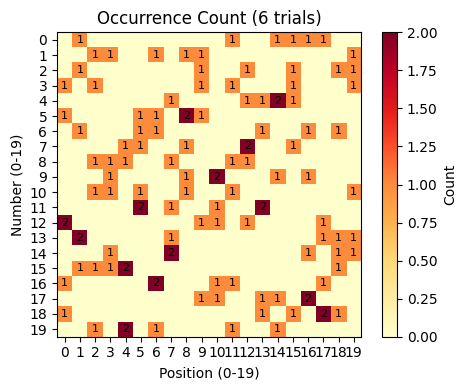

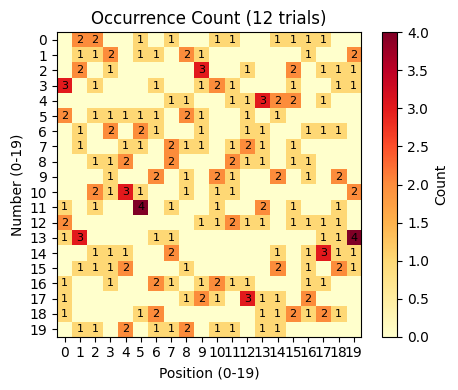

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

def get_occurrence_matrix(pool, num_range=20):
    # Matrix: Rows = Numbers (0-19), Cols = Positions (0-19)
    matrix = np.zeros((num_range, num_range), dtype=int)
    for trial in pool:
        for pos, val in enumerate(trial):
            matrix[val, pos] += 1
    return matrix

# Data generation
num_range = 20
random.seed(0)
pool_6 = [random.sample(range(num_range), num_range) for _ in range(6)]

random.seed(0)
pool_12 = [random.sample(range(num_range), num_range) for _ in range(12)]

matrix_6 = get_occurrence_matrix(pool_6)
matrix_12 = get_occurrence_matrix(pool_12)

# Visualization
def plot_heatmap(matrix, title, filename):
    plt.figure(figsize=(5, 4))
    im = plt.imshow(matrix, cmap='YlOrRd')
    plt.colorbar(im, label='Count')
    plt.xlabel('Position (0-19)')
    plt.ylabel('Number (0-19)')
    plt.title(title)
    plt.xticks(range(20))
    plt.yticks(range(20))
    # Add text annotations
    for i in range(20):
        for j in range(20):
            if matrix[i, j] > 0:
                plt.text(j, i, str(matrix[i, j]), ha="center", va="center", color="black", fontsize=8)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()

plot_heatmap(matrix_6, 'Occurrence Count (6 trials)', 'counts_6.png')
plot_heatmap(matrix_12, 'Occurrence Count (12 trials)', 'counts_12.png')


print("Max count in 6 trials:", np.max(matrix_6))
print("Number of overlapping cells (count > 1) in 6 trials:", np.sum(matrix_6 > 1))
print("Max count in 12 trials:", np.max(matrix_12))
print("Number of overlapping cells (count > 1) in 12 trials:", np.sum(matrix_12 > 1))

In [ ]:
import random
random.seed(0)
trial_orders_pool = [random.sample(range(20), 20) for _ in range(6)]
for i in trial_orders_pool:
  print(i)

print("*"*100)

random.seed(0)
trial_orders_pool = [random.sample(range(20), 20) for _ in range(12)]
for i in trial_orders_pool:
  print(i)

[12, 13, 1, 8, 15, 6, 19, 4, 7, 5, 9, 3, 2, 11, 17, 0, 14, 16, 18, 10]
[3, 2, 10, 15, 19, 5, 6, 14, 9, 17, 16, 8, 7, 11, 4, 18, 0, 12, 13, 1]
[12, 0, 15, 10, 7, 11, 5, 14, 1, 3, 9, 16, 8, 6, 19, 4, 17, 18, 2, 13]
[16, 15, 3, 9, 19, 11, 1, 8, 5, 12, 17, 10, 4, 18, 0, 7, 6, 13, 14, 2]
[5, 6, 19, 1, 8, 7, 16, 13, 10, 2, 11, 0, 12, 17, 4, 3, 9, 18, 15, 14]
[18, 13, 8, 14, 15, 10, 16, 11, 5, 1, 12, 19, 7, 4, 9, 2, 17, 0, 6, 3]
****************************************************************************************************
[12, 13, 1, 8, 15, 6, 19, 4, 7, 5, 9, 3, 2, 11, 17, 0, 14, 16, 18, 10]
[3, 2, 10, 15, 19, 5, 6, 14, 9, 17, 16, 8, 7, 11, 4, 18, 0, 12, 13, 1]
[12, 0, 15, 10, 7, 11, 5, 14, 1, 3, 9, 16, 8, 6, 19, 4, 17, 18, 2, 13]
[16, 15, 3, 9, 19, 11, 1, 8, 5, 12, 17, 10, 4, 18, 0, 7, 6, 13, 14, 2]
[5, 6, 19, 1, 8, 7, 16, 13, 10, 2, 11, 0, 12, 17, 4, 3, 9, 18, 15, 14]
[18, 13, 8, 14, 15, 10, 16, 11, 5, 1, 12, 19, 7, 4, 9, 2, 17, 0, 6, 3]
[3, 7, 11, 5, 10, 6, 13, 0, 1, 2, 19, 12, 17, 8

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

------------------------------
素晴らしいですね！Qwen 1.5の実行に成功したことをお贺び申し上げます！これ标志着あなたの技術や努力の成果です。これからもより高度で便利なサポートをお届けするために頑張ってくださいね。おめでとうございます！


In [ ]:
print(model.config.architectures)

['Qwen2ForCausalLM']


In [ ]:
import torch
import torch.nn as nn
from typing import Optional, Tuple, Callable, Union

# 設定とキャッシュ管理
from transformers.models.qwen2.configuration_qwen2 import Qwen2Config
from transformers.cache_utils import Cache

# ユーティリティと型定義
from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS
from transformers.utils import logging, deprecate_kwarg
try:
    from typing import Unpack
except ImportError:
    from typing_extensions import Unpack

# 型ヒント (Qwen2特有)
from transformers.utils import FlashAttentionKwargs

# 計算ロジック (Llamaのものを流用)
from transformers.models.llama.modeling_llama import (
    apply_rotary_pos_emb,
    eager_attention_forward,
)

logger = logging.get_logger(__name__)

class Qwen2Attention(LlamaAttention):
    def __init__(self, config: Qwen2Config, layer_idx: int):
        super().__init__(config, layer_idx)
        self.q_proj = nn.Linear(config.hidden_size, config.num_attention_heads * self.head_dim, bias=True)
        self.k_proj = nn.Linear(config.hidden_size, config.num_key_value_heads * self.head_dim, bias=True)
        self.v_proj = nn.Linear(config.hidden_size, config.num_key_value_heads * self.head_dim, bias=True)
        self.o_proj = nn.Linear(config.num_attention_heads * self.head_dim, config.hidden_size, bias=False)
        self.sliding_window = config.sliding_window if config.layer_types[layer_idx] == "sliding_attention" else None

    @deprecate_kwarg("past_key_value", new_name="past_key_values", version="4.58")
    def forward(
        self,
        hidden_states: torch.Tensor,
        position_embeddings: tuple[torch.Tensor, torch.Tensor],
        attention_mask: Optional[torch.Tensor],
        past_key_values: Optional[Cache] = None,
        cache_position: Optional[torch.LongTensor] = None,
        **kwargs: Unpack[FlashAttentionKwargs],
    ) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)

        query_states = self.q_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        key_states = self.k_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

        cos, sin = position_embeddings
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_values is not None:
            # sin and cos are specific to RoPE models; cache_position needed for the static cache
            cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
            key_states, value_states = past_key_values.update(key_states, value_states, self.layer_idx, cache_kwargs)

        attention_interface: Callable = eager_attention_forward
        if self.config._attn_implementation != "eager":
            attention_interface = ALL_ATTENTION_FUNCTIONS[self.config._attn_implementation]

        attn_output, attn_weights = attention_interface(
            self,
            query_states,
            key_states,
            value_states,
            attention_mask,
            dropout=0.0 if not self.training else self.attention_dropout,
            scaling=self.scaling,
            sliding_window=self.sliding_window,  # main diff with Llama
            **kwargs,
        )

        attn_output = attn_output.reshape(*input_shape, -1).contiguous()
        attn_output = self.o_proj(attn_output)
        return attn_output, attn_weights

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. モデルIDの指定
# 他のサイズ: "Qwen/Qwen1.5-1.8B-Chat", "Qwen/Qwen1.5-4B-Chat" など
model_id = "Qwen/Qwen1.5-7B-Chat"

# 3. トークナイザーとモデルのロード
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    dtype = "auto"
)

# 4. 会話ログの準備 (ChatML形式)
messages = [
    {"role": "system", "content": "あなたは優秀で簡潔に答えるアシスタントです。"},
    {"role": "user", "content": "Qwen 1.5を動かすことに成功しました！お祝いのメッセージをください。日本語で。"}
]

# 5. プロンプトの組み立て (Qwen専用テンプレート適用)
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

# 6. 入力のトークナイズ
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# 7. テキスト生成
generated_ids = model.generate(
    model_inputs.input_ids,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    pad_token_id=tokenizer.eos_token_id
)

# 8. 結果のデコード (入力部分をカット)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("-" * 30)
print(response)

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
LOG_DIR = "/content/drive/MyDrive/Research_Logs"

print(f"✅ ログ保存先: {LOG_DIR}")

%pip install xopen

from pathlib import Path
import sys
import torch
from datasets import load_dataset
from datetime import datetime
import xopen
import random

import huggingface_hub
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(hf_token)

random.seed(0)


# 以下自作モジュール
module_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/my_modules"
if module_path not in sys.path:
    sys.path.append(module_path)

from get_model_safe_last_attnweight import get_model_safe, test_patched_model_sanity, remove_cache

def confirmation():
    """実行前にユーザーの確認を求める"""
    print("\n" + "!" * 30)
    print("警告: 書き出しモードが 'a' (追記) です。")
    print("既存のファイルにデータが追加されますが、よろしいですか？")
    print("!" * 30 + "\n")

    answer = input("実行する場合は 'yes' と入力してください: ").strip().lower()

    if answer != 'yes':
        print("\n[中止] 実行がキャンセルされました。")
        # Jupyterでセルを止める最もクリーンな方法
        raise KeyboardInterrupt("User cancelled the execution.")

    print("\n[開始] 実験を実行します...\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ログ保存先: /content/drive/MyDrive/Research_Logs


In [ ]:
MODEL_NAME = "lmsys/vicuna-7b-v1.5"
# model, tokenizer = get_model_safe_last_attnweight(MODEL_NAME)
test_patched_model_sanity(MODEL_NAME)

🔬 Starting Model Sanity Check...
----------------------------------------
⏳ Loading new model... (This may take a while)


tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔄 Swapping Attention Modules to DynamicScalingLlamaAttention...
✅ Model loaded and patched successfully.
🧐 Checking Layer 0 Attention Class...
   -> Detected: DynamicScalingLlamaAttention
   ✅ SUCCESS: Attention module is correctly swapped!

🏃 Running Basic Generation Test (No Scaling)...
   -> Output: Hello, my name is Jovana and I am a 22
   ✅ Basic generation passed.

💉 Running Scaled Generation Test (With Dummy Map)...
   -> Output: Hello, my name is Jovana and I am a 22
   ✅ Scaled generation passed! (Logic seems correct)
----------------------------------------
🎉 Test Complete.
